# D3 - Pengolahan Citra Dasar dan Channel Warna OpenCV

## 1. Koneksi Google Colab dengan Google Drive

Folder: `PCVK/Minggu 1/images`

File:
- `gambar_latihan.jpg` (kitten, lena, mandrill, male, female, couple, sailboat, atau peppers)
- `foto_aktivitas.jpg`
- `ktm.jpg`

Jalankan cell, pilih akun Google, lalu izinkan akses Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Output berhasil: `Mounted at /content/drive`

In [2]:
from pathlib import Path

folder_drive = Path('/content/drive/MyDrive/PCVK/Minggu 1/images')
path_gambar = folder_drive / 'gambar_latihan.jpg'
path_foto = folder_drive / 'foto_aktivitas.jpg'
path_ktm = folder_drive / 'ktm.jpg'

for path in [path_gambar, path_foto, path_ktm]:
    if not path.exists():
        raise FileNotFoundError(f'File tidak ditemukan: {path}')
    print(f'Ditemukan: {path.name}')

Ditemukan: gambar_latihan.jpg
Ditemukan: foto_aktivitas.jpg
Ditemukan: ktm.jpg


### Upload dari laptop

In [3]:
from google.colab import files
uploaded = files.upload()

In [4]:
import cv2
from google.colab.patches import cv2_imshow

if 'uploaded' in globals() and uploaded:
    nama_file_upload = next(iter(uploaded))
    img_upload = cv2.imread(nama_file_upload)
    if img_upload is None:
        raise ValueError(f'Gambar gagal dibaca: {nama_file_upload}')
    cv2_imshow(img_upload)
else:
    print('Upload dibatalkan. Gambar akan dibaca dari Google Drive.')

Upload dibatalkan. Gambar akan dibaca dari Google Drive.


## 2. Menampilkan Gambar dengan Matplotlib

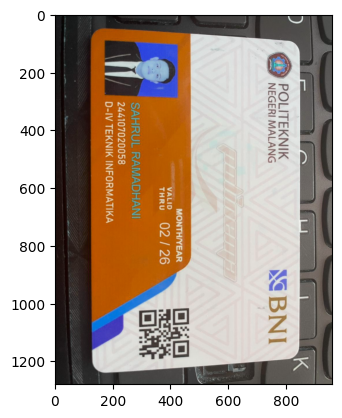

In [5]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from skimage import io

img = cv2.imread('/content/drive/MyDrive/PCVK/Minggu 1/images/ktm.jpg')
plt.imshow(img)

### Konversi BGR ke RGB

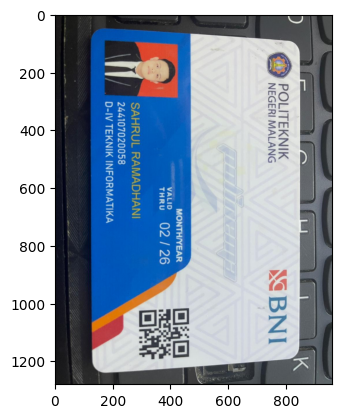

In [6]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Minggu 1/images/ktm.jpg')
img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img2)

### Konversi dan penampilan secara langsung

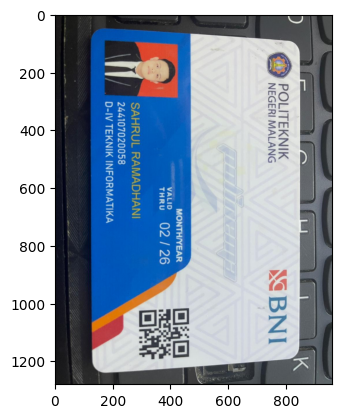

In [7]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Minggu 1/images/ktm.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

## 3. Menampilkan Citra Grayscale

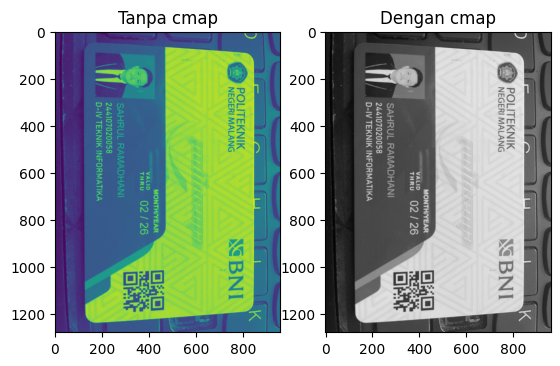

In [8]:
img_gray = cv2.imread('/content/drive/MyDrive/PCVK/Minggu 1/images/ktm.jpg', cv2.IMREAD_GRAYSCALE)

plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

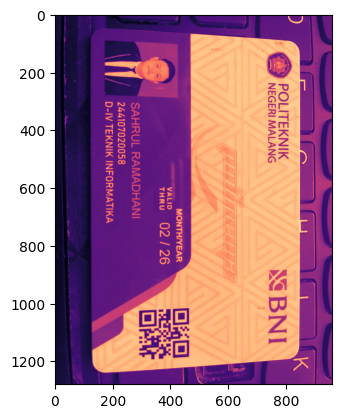

In [9]:
plt.imshow(img_gray, cmap='magma')

## 4. Melakukan Resizing

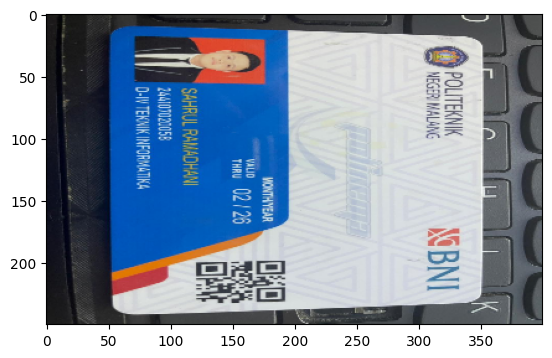

In [10]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Minggu 1/images/ktm.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
imgRGBsmall = cv2.resize(imgRGB, (400,250))
plt.imshow(imgRGBsmall)

## 5. Melakukan Flipping

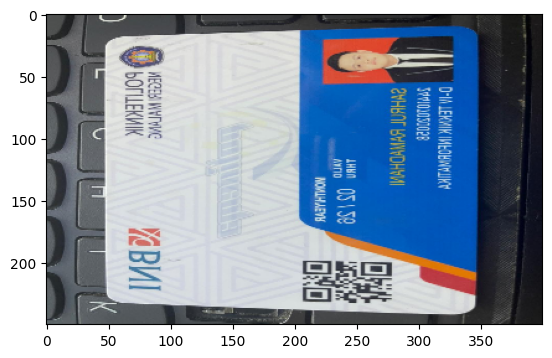

In [11]:
imgBalik=cv2.flip(imgRGBsmall,1)
plt.imshow(imgBalik)

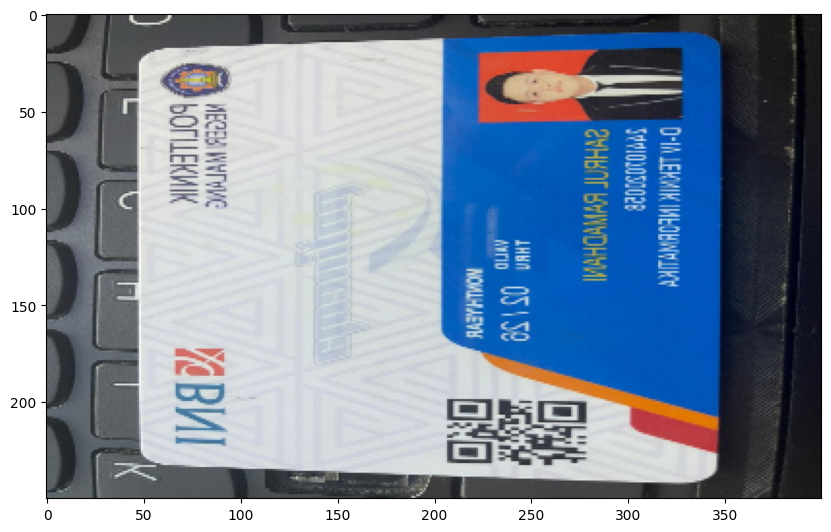

In [12]:
imgBalik=cv2.flip(imgRGBsmall,1)

fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111)
ax.imshow(imgBalik)

## 6. Membuat Bentuk Geometri 2D dari OpenCV

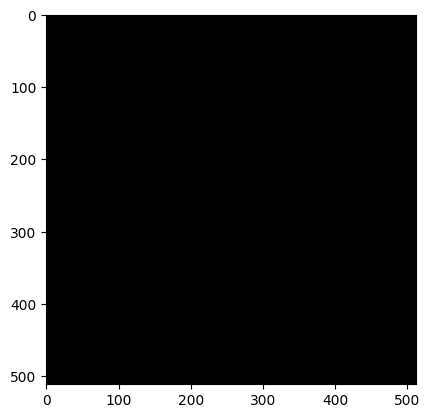

In [13]:
import numpy as np
import cv2 as cv

black_img = np.zeros(shape=(512,512,3),dtype=np.int16)
plt.imshow(black_img)

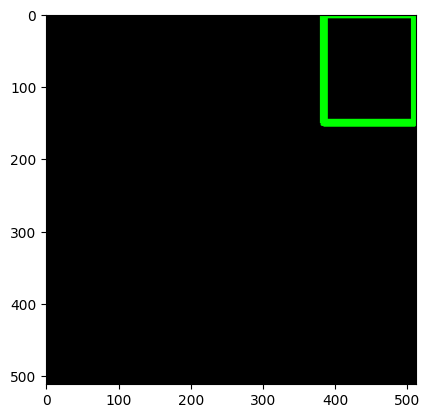

In [14]:
cv.rectangle(black_img,pt1=(384,0),pt2=(510,150),color=(0,255,0),thickness=10)
plt.imshow(black_img)

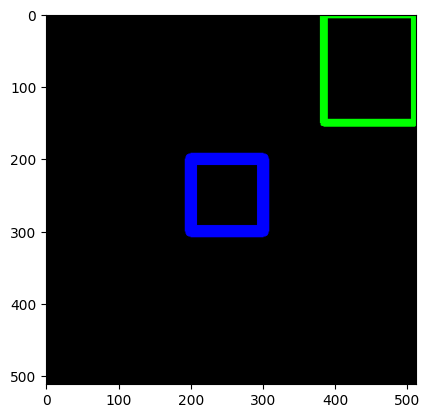

In [15]:
cv.rectangle(black_img,pt1=(200,200),pt2=(300,300),color=(0,0,255),thickness=15)
plt.imshow(black_img)

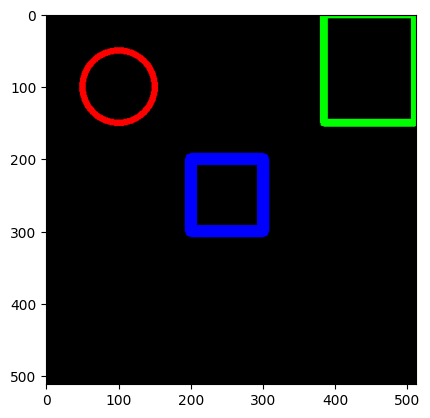

In [16]:
cv.circle(black_img,center=(100,100),radius=50,color=(255,0,0),thickness=8)
plt.imshow(black_img)

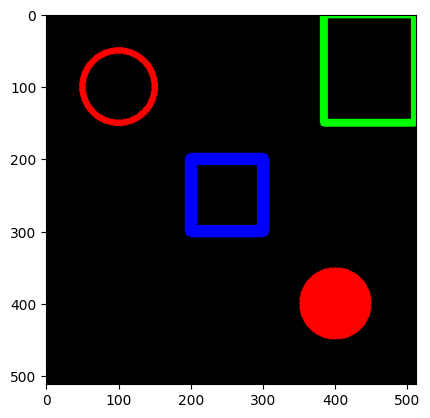

In [17]:
cv.circle(black_img,center=(400,400),radius=50,color=(255,0,0),thickness=-1)
plt.imshow(black_img)

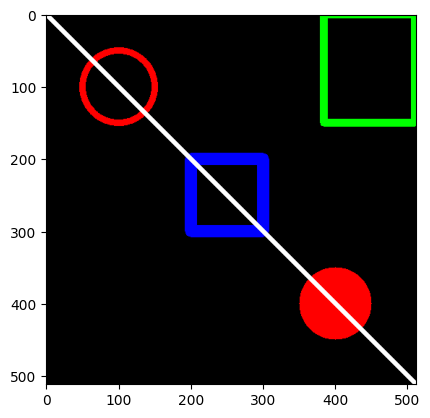

In [18]:
cv.line(black_img,pt1=(0,0),pt2=(512,512),color=(255,255,255),thickness=5)
plt.imshow(black_img)

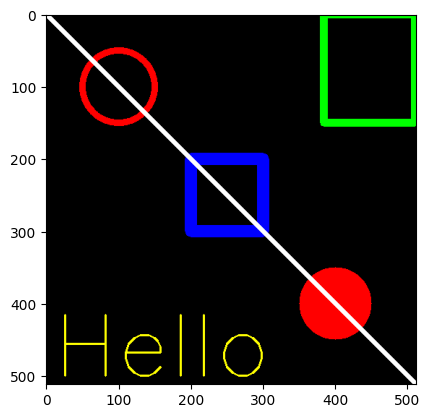

In [19]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='Hello',org=(10,500),fontFace=font,fontScale=4,color=(255,255,0),thickness=2,lineType=cv.LINE_AA)
plt.imshow(black_img)

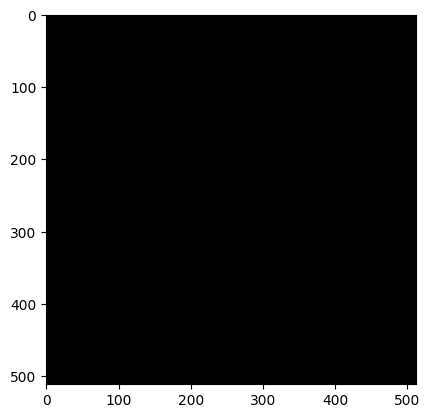

In [20]:
black_img2=np.zeros(shape=(512,512,3),dtype=np.int32)
plt.imshow(black_img2)

In [21]:
vertices = np.array([[100,300],[200,200],[400,300],[200,400]],dtype=np.int32)
vertices

array([[100, 300],
       [200, 200],
       [400, 300],
       [200, 400]], dtype=int32)

In [22]:
pts = vertices.reshape((-1,1,2))
pts

array([[[100, 300]],

       [[200, 200]],

       [[400, 300]],

       [[200, 400]]], dtype=int32)

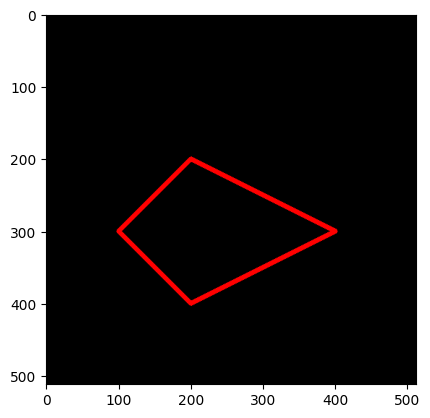

In [23]:
cv.polylines(black_img2,[pts],isClosed=True,color=(255,0,0),thickness=5)
plt.imshow(black_img2)

# Pertanyaan Praktikum D3

## 1. Perbedaan gambar tanpa dan dengan Matplotlib
`cv2_imshow` menampilkan gambar secara langsung. Matplotlib menampilkan gambar dalam plot sehingga ukuran, judul, dan warna tampilannya dapat diatur. OpenCV memakai BGR, sedangkan Matplotlib memakai RGB.

## 2. Perbedaan black image int16 dan int32
`int16` memakai 16 bit, sedangkan `int32` memakai 32 bit. `int32` dapat menyimpan nilai lebih besar, tetapi memakai memori lebih banyak. Hasil black image tetap sama karena nilai awalnya nol.

## 3. Kegunaan `google.colab.patches import cv2_imshow`
Perintah tersebut digunakan untuk menampilkan gambar OpenCV di Google Colab. `cv2_imshow` dipakai sebagai pengganti `cv2.imshow` yang tidak berjalan langsung di Colab.

## 4. Kegunaan `skimage import io`
`io` digunakan untuk membaca gambar, termasuk gambar yang berasal dari URL.

# Tugas Praktikum D3

(np.float64(-0.5), np.float64(1023.5), np.float64(624.5), np.float64(-0.5))

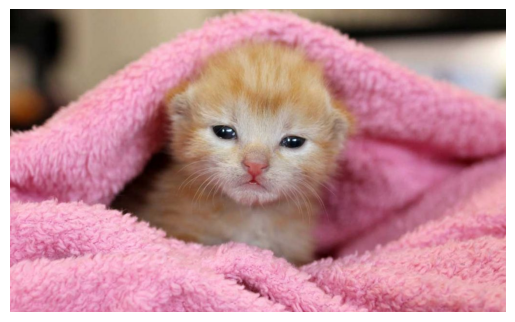

In [24]:
img_bgr = cv2.imread(str(path_gambar))
if img_bgr is None:
    raise ValueError(f'Gambar gagal dibaca: {path_gambar}')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')

## Tugas 1 - Pengaruh figsize

Ukuran pixel: (625, 1024, 3)


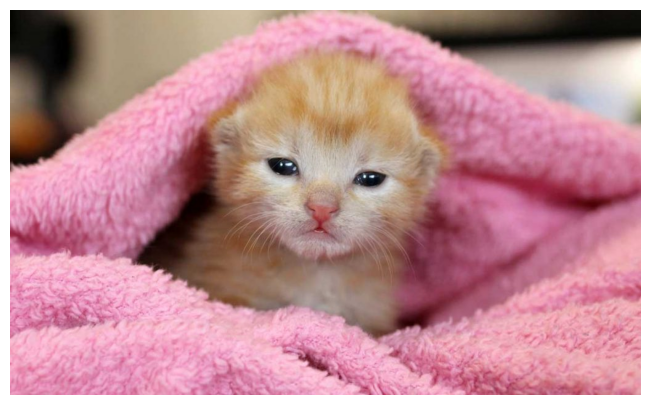

Ukuran pixel setelah figsize: (625, 1024, 3)


In [25]:
print('Ukuran pixel:', img_rgb.shape)
plt.figure(figsize=(15,5))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()
print('Ukuran pixel setelah figsize:', img_rgb.shape)

`figsize` mengubah ukuran canvas Matplotlib, bukan jumlah pixel pada array citra.

## Tugas 2 - Channel Red-Blue dan Green-Blue

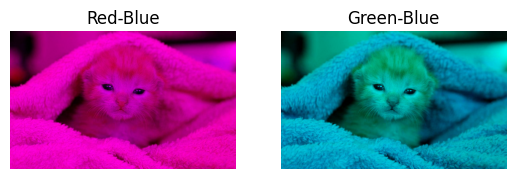

In [26]:
img_red_blue = img_rgb.copy()
img_red_blue[:,:,1] = 0

img_green_blue = img_rgb.copy()
img_green_blue[:,:,0] = 0

plt.subplot(1,2,1)
plt.imshow(img_red_blue)
plt.title('Red-Blue')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_green_blue)
plt.title('Green-Blue')
plt.axis('off')
plt.show()

## Tugas 3 - Baris 20-115 dan Kolom 25-120

(np.float64(-0.5), np.float64(95.5), np.float64(95.5), np.float64(-0.5))

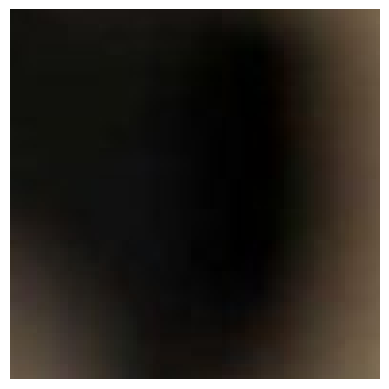

In [27]:
img_crop = img_rgb[20:116,25:121]
plt.imshow(img_crop)
plt.axis('off')

## Tugas 4 - Baris 5-30, Semua Kolom, Channel Red

(np.float64(-0.5), np.float64(1023.5), np.float64(25.5), np.float64(-0.5))

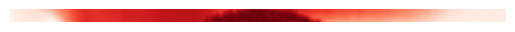

In [28]:
img_red = img_rgb[5:31,:,0]
plt.imshow(img_red, cmap='Reds')
plt.axis('off')

## Tugas 5 - Lima Kotak Acak

(np.float64(-0.5), np.float64(1023.5), np.float64(624.5), np.float64(-0.5))

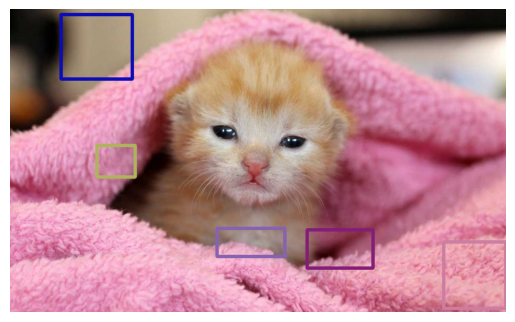

In [29]:
import random

img_kotak = img_rgb.copy()
tinggi, lebar = img_kotak.shape[:2]

for i in range(5):
    x1 = random.randint(0, lebar-100)
    y1 = random.randint(0, tinggi-100)
    x2 = min(lebar-1, x1+random.randint(30,150))
    y2 = min(tinggi-1, y1+random.randint(30,150))
    warna = tuple(random.randint(0,255) for j in range(3))
    cv.rectangle(img_kotak,(x1,y1),(x2,y2),warna,5)

plt.imshow(img_kotak)
plt.axis('off')

## Tugas 6 - Posisi Terbalik

(np.float64(-0.5), np.float64(1023.5), np.float64(624.5), np.float64(-0.5))

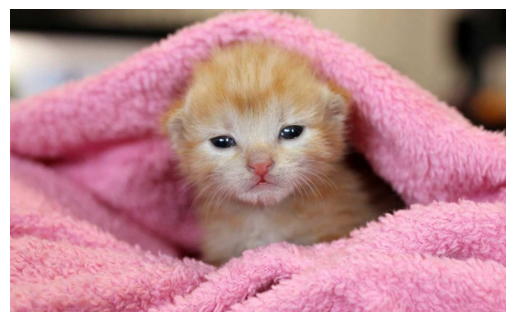

In [30]:
img_terbalik = cv.flip(img_rgb,1)
plt.imshow(img_terbalik)
plt.axis('off')

## Tugas 7 - Rectangle dan Circle pada Wajah

(np.float64(-0.5), np.float64(1151.5), np.float64(647.5), np.float64(-0.5))

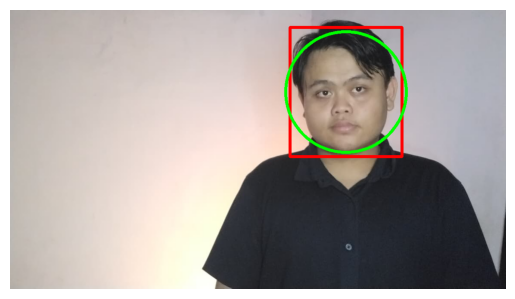

In [31]:
foto_bgr = cv2.imread(str(path_foto))
if foto_bgr is None:
    raise ValueError(f'Foto gagal dibaca: {path_foto}')
foto_rgb = cv2.cvtColor(foto_bgr, cv2.COLOR_BGR2RGB)

cv.rectangle(foto_rgb,(650,40),(910,340),(255,0,0),5)
cv.circle(foto_rgb,(780,190),140,(0,255,0),5)

plt.imshow(foto_rgb)
plt.axis('off')

## Tugas 8 dan 9 - Rectangle Channel B dan Nama File

(np.float64(-0.5), np.float64(1023.5), np.float64(624.5), np.float64(-0.5))

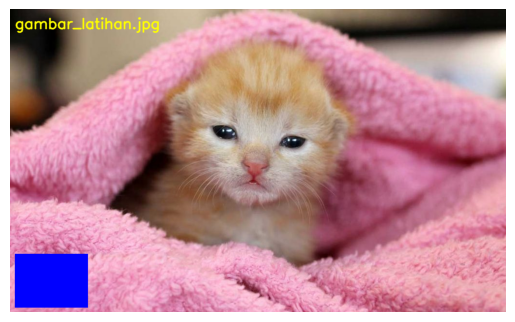

In [32]:
img_tugas89 = img_rgb.copy()
tinggi, lebar = img_tugas89.shape[:2]

cv.rectangle(img_tugas89,(10,tinggi-120),(160,tinggi-10),(0,0,255),-1)
cv.putText(img_tugas89,path_gambar.name,(10,40),cv.FONT_HERSHEY_SIMPLEX,1,(255,255,0),2,cv.LINE_AA)

plt.imshow(img_tugas89)
plt.axis('off')

## Tugas 10
Tunjukkan seluruh kode dan output kepada bapak/ibu dosen.

# Tugas Praktikum Kelompok

## Kelompok 6
Tampilkan KTM menggunakan OpenCV dan Matplotlib. Tutup tulisan `MONTH/YEAR`, tulisan `VALID THRU`, dan angka masa berlaku.

Dikarenakan Kelompok 6 tidak ada yang pilih, disini saya memutuskan untuk memilih kelompok 6 dengan menambahkan Lingkaran hijau untuk menutup VALID THRU, Segi delapan merah untuk menutup MONTH/YEAR dan Garis tebal biru untuk menutup angka 02/26.

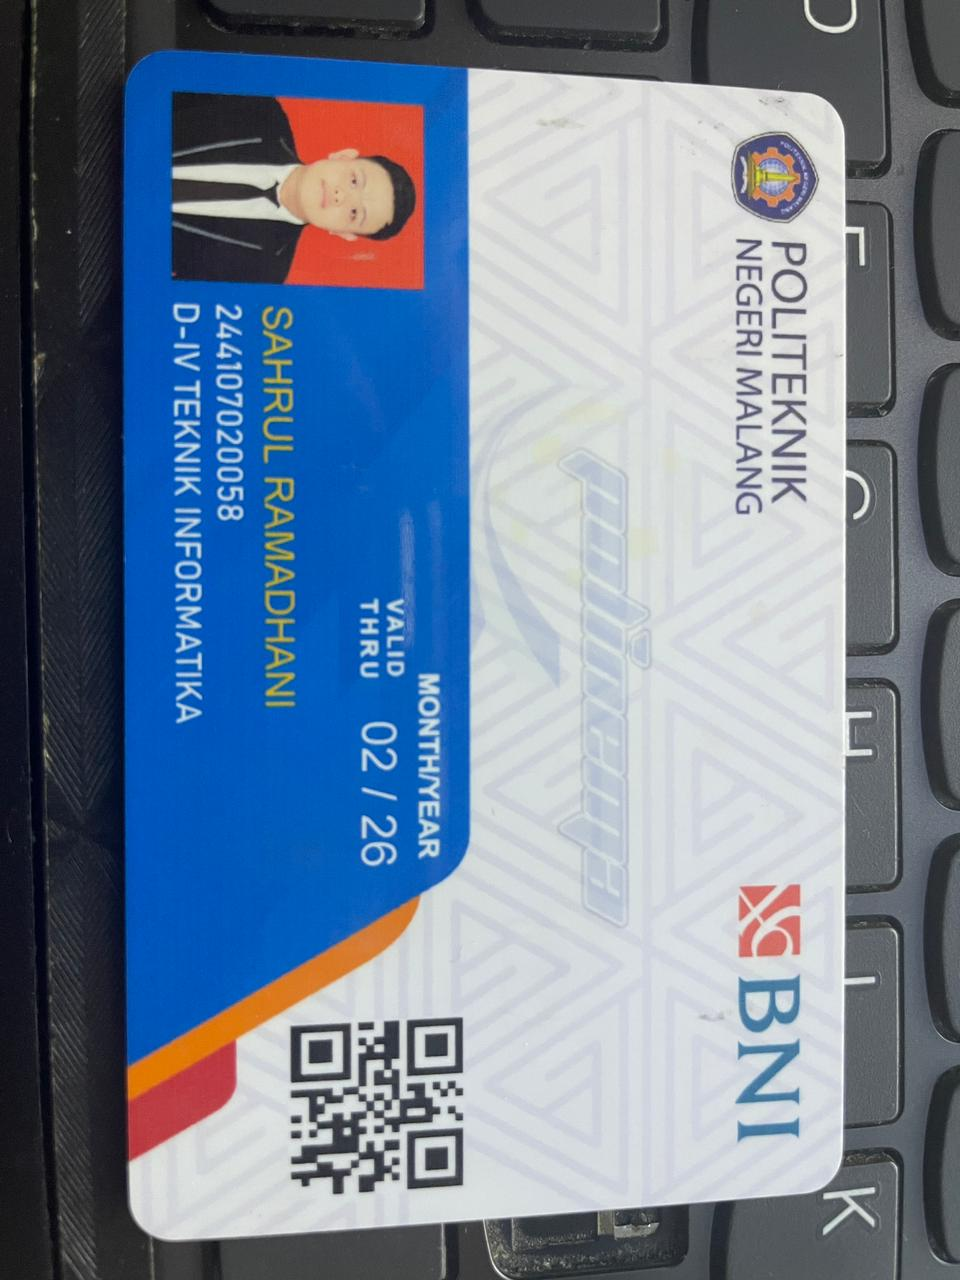

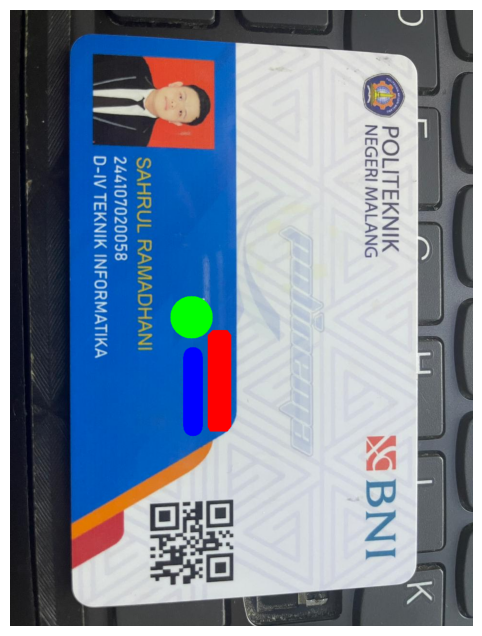

In [33]:
ktm_bgr = cv2.imread(str(path_ktm))
if ktm_bgr is None:
    raise ValueError(f'KTM gagal dibaca: {path_ktm}')
cv2_imshow(ktm_bgr)

ktm_rgb = cv2.cvtColor(ktm_bgr, cv2.COLOR_BGR2RGB)
hasil_ktm = ktm_rgb.copy()

segi_delapan = np.array([[420,665],[450,665],[458,675],[458,865],[450,875],[415,875],[410,865],[410,675]],np.int32)
cv.fillPoly(hasil_ktm,[segi_delapan],(255,0,0))
cv.circle(hasil_ktm,(376,638),44,(0,255,0),-1)
cv.line(hasil_ktm,(379,720),(379,865),(0,0,255),40)

plt.figure(figsize=(12,8))
plt.imshow(hasil_ktm)
plt.axis('off')
plt.show()